In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [13]:
from imblearn.over_sampling import SMOTE


In [2]:
# Load Data
df = pd.read_csv('/content/Pima Indians Diabetes Dataset.csv')

In [3]:
# Replace zeros with NaN for specific columns (biologically impossible values)
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [4]:
# Fill missing values with column means
df.fillna(df.mean(), inplace=True)

In [5]:
# Remove outliers using IQR
def remove_outliers(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

df = remove_outliers(df, df.columns[:-1])

In [6]:
# Split into features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [30]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [26]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

In [33]:
log_grid = GridSearchCV(log_reg, log_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
log_grid.fit(X_train_res, y_train_res)
best_log_model = log_grid.best_estimator_

In [34]:
print("Best Logistic Regression Parameters:", log_grid.best_params_)
y_pred_log = best_log_model.predict(X_test)

Best Logistic Regression Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [35]:
print("\nLogistic Regression After Tuning:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
log_auc = roc_auc_score(y_test, best_log_model.predict_proba(X_test)[:, 1])
print("AUC Score:", log_auc)


Logistic Regression After Tuning:
Confusion Matrix:
 [[48 13]
 [11 21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        61
           1       0.62      0.66      0.64        32

    accuracy                           0.74        93
   macro avg       0.72      0.72      0.72        93
weighted avg       0.75      0.74      0.74        93

AUC Score: 0.8022540983606558


In [38]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [39]:
xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_res, y_train_res)
best_xgb_model = xgb_grid.best_estimator_

In [40]:
print("\nBest XGBoost Parameters:", xgb_grid.best_params_)
y_pred_xgb = best_xgb_model.predict(X_test)


Best XGBoost Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}


In [41]:
print("\nXGBoost After Tuning:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
xgb_auc = roc_auc_score(y_test, best_xgb_model.predict_proba(X_test)[:, 1])
print("AUC Score:", xgb_auc)


XGBoost After Tuning:
Confusion Matrix:
 [[49 12]
 [12 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        61
           1       0.62      0.62      0.62        32

    accuracy                           0.74        93
   macro avg       0.71      0.71      0.71        93
weighted avg       0.74      0.74      0.74        93

AUC Score: 0.8104508196721312


In [42]:
log_fpr, log_tpr, _ = roc_curve(y_test, best_log_model.predict_proba(X_test)[:,1])
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, best_xgb_model.predict_proba(X_test)[:,1])

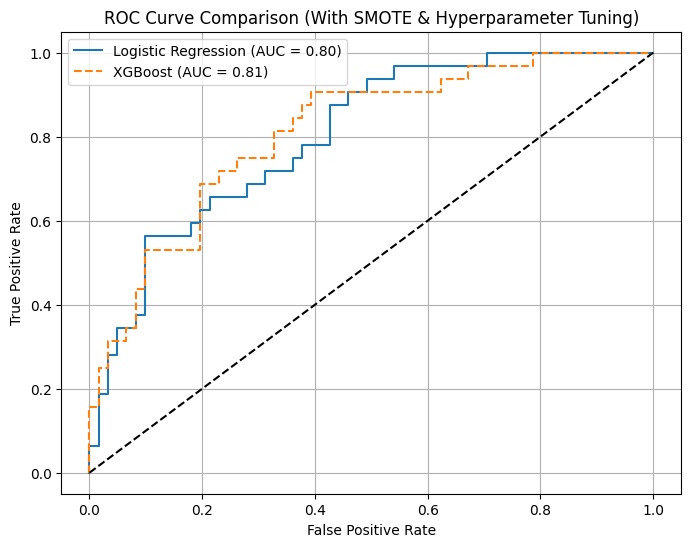

In [43]:
plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (With SMOTE & Hyperparameter Tuning)')
plt.legend()
plt.grid(True)
plt.show()